In [39]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

import yfinance as yf
import pandas_datareader as pdr

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
print("=" * 65)
print("STEP 1 — Downloading market & macro data")
print("=" * 65)

START, END = "2000-01-01", "2025-01-01"

STEP 1 — Downloading market & macro data


In [3]:
# ── QQQ ───────────────────────────────────────────────────────────────────────
print("  Downloading QQQ...")
qqq_raw = yf.download("QQQ", start=START, end=END, interval="1d", auto_adjust=True)
qqq_raw.columns = qqq_raw.columns.get_level_values(0)
qqq = qqq_raw[["Close"]].rename(columns={"Close": "QQQ"})
qqq.index = pd.to_datetime(qqq.index).tz_localize(None)

[*********************100%***********************]  1 of 1 completed


In [4]:
# ── VIX ───────────────────────────────────────────────────────────────────────
print("  Downloading VIX...")
vix_raw = yf.download("^VIX", start=START, end=END, interval="1d", auto_adjust=True)
vix_raw.columns = vix_raw.columns.get_level_values(0)
vix_x = vix_raw[["Close"]].rename(columns={"Close": "VIX"})
vix_x.index = pd.to_datetime(vix_x.index).tz_localize(None)

[*********************100%***********************]  1 of 1 completed


In [12]:
print("  Downloading FRED data...")
epu           = pdr.DataReader("USEPUINDXD", "fred", START, END)
consumer_sent = pdr.DataReader("UMCSENT",    "fred", START, END)
jobless       = pdr.DataReader("ICSA",       "fred", START, END)
cpi_raw       = pdr.DataReader("CPIAUCSL",   "fred", START, END)
fed           = pdr.DataReader("FEDFUNDS",   "fred", START, END)
flows         = pdr.DataReader("WLEMUINDXD", "fred", START, END)

cpi_raw["INFLATION"] = cpi_raw["CPIAUCSL"].pct_change(12) * 100
cpi_x             = cpi_raw[["INFLATION"]]
epu.columns           = ["EPU"]
consumer_sent.columns = ["SENTIMENT"]
jobless.columns       = ["JOBLESS"]
fed.columns           = ["FED_RATE"]
flows.columns         = ["FLOWS"]

print("  ✅ All raw data downloaded.\n")

ReadTimeout: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Read timed out. (read timeout=30)

In [13]:
from fredapi import Fred
import os
import time

FRED_API_KEY = "5762c92c12aa3d0c08e3f67ebf03f144"  

fred = Fred(api_key=FRED_API_KEY)

CACHE_DIR = "./fred_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def fred_with_cache(series_id, start, end, retries=3):
    path = f"{CACHE_DIR}/{series_id}.csv"
    if os.path.exists(path):
        print(f"  📂 {series_id} — from cache")
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index).tz_localize(None)
        return df
    for i in range(retries):
        try:
            s  = fred.get_series(series_id, start, end)
            df = s.to_frame(name=series_id)
            df.to_csv(path)
            print(f"  ✅ {series_id} — downloaded & cached")
            return df
        except Exception as e:
            wait = (i + 1) * 5
            print(f"  ⚠️  {series_id} attempt {i+1} failed: {e}, retry in {wait}s")
            time.sleep(wait)
    raise RuntimeError(f"❌ {series_id} failed after {retries} attempts")

print("  Downloading FRED data...")
epu           = fred_with_cache("USEPUINDXD", START, END)
consumer_sent = fred_with_cache("UMCSENT",    START, END)
jobless       = fred_with_cache("ICSA",       START, END)
cpi_raw       = fred_with_cache("CPIAUCSL",   START, END)
fed           = fred_with_cache("FEDFUNDS",   START, END)
flows         = fred_with_cache("WLEMUINDXD", START, END)

cpi_raw["INFLATION"] = cpi_raw["CPIAUCSL"].pct_change(12) * 100
cpi_x             = cpi_raw[["INFLATION"]]
epu.columns           = ["EPU"]
consumer_sent.columns = ["SENTIMENT"]
jobless.columns       = ["JOBLESS"]
fed.columns           = ["FED_RATE"]
flows.columns         = ["FLOWS"]

print("  ✅ All FRED data ready.\n")

  ✅ USEPUINDXD — downloaded & cached
  ✅ UMCSENT — downloaded & cached
  ✅ ICSA — downloaded & cached
  ✅ CPIAUCSL — downloaded & cached
  ✅ FEDFUNDS — downloaded & cached
  ✅ WLEMUINDXD — downloaded & cached
  ✅ All FRED data ready.



In [14]:
print("=" * 65)
print("STEP 2 — Building Event Flags  (Earnings + FOMC)")
print("=" * 65)

STEP 2 — Building Event Flags  (Earnings + FOMC)


In [15]:
TOP5 = {
    "AAPL" : 0.089,
    "MSFT" : 0.086,
    "NVDA" : 0.082,
    "AMZN" : 0.052,
    "GOOGL": 0.044,
}
EARN_WINDOW = 3  

trading_days = qqq.index

def fetch_earnings_dates(ticker: str, start: str, end: str) -> pd.DatetimeIndex:
    """
    Fetch historical earnings announcement dates from yfinance.
    Note: coverage is typically reliable from ~2015 onward.
    Earlier dates may be sparse or missing.
    """
    tk = yf.Ticker(ticker)
    try:
        ed = tk.earnings_dates
        if ed is None or ed.empty:
            return pd.DatetimeIndex([])
        dates = pd.DatetimeIndex(ed.index).tz_localize(None)
        return dates[(dates >= start) & (dates < end)]
    except Exception as e:
        print(f"    ⚠️  {ticker} earnings fetch failed: {e}")
        return pd.DatetimeIndex([])

In [16]:
print("  Fetching earnings dates for top-5 constituents...")
weighted_flag = pd.Series(0.0, index=trading_days, name="EARN_FLAG_W")

for ticker, weight in TOP5.items():
    dates = fetch_earnings_dates(ticker, START, END)
    print(f"    {ticker}: {len(dates)} dates  "
          f"({'⚠️ sparse — reliability ~2015+' if len(dates) < 60 else '✅'})")
    for ed in dates:
        idx_c = trading_days[trading_days >= ed]
        if len(idx_c) == 0:
            continue
        anchor = idx_c[0]
        pos    = trading_days.get_loc(anchor)
        lo     = max(0, pos - EARN_WINDOW)
        hi     = min(len(trading_days) - 1, pos + EARN_WINDOW)
        weighted_flag.iloc[lo:hi+1] += weight

print(f"  ✅ EARN_FLAG_W built. Non-zero days: {(weighted_flag > 0).sum()}")

  Fetching earnings dates for top-5 constituents...
    AAPL: 19 dates  (⚠️ sparse — reliability ~2015+)
    MSFT: 19 dates  (⚠️ sparse — reliability ~2015+)
    NVDA: 19 dates  (⚠️ sparse — reliability ~2015+)
    AMZN: 19 dates  (⚠️ sparse — reliability ~2015+)
    GOOGL: 19 dates  (⚠️ sparse — reliability ~2015+)
  ✅ EARN_FLAG_W built. Non-zero days: 344


In [17]:
FOMC_DATES = pd.to_datetime([
    "2020-01-29","2020-03-03","2020-03-15","2020-04-29","2020-06-10",
    "2020-07-29","2020-09-16","2020-11-05","2020-12-16",
    "2021-01-27","2021-03-17","2021-04-28","2021-06-16","2021-07-28",
    "2021-09-22","2021-11-03","2021-12-15",
    "2022-01-26","2022-03-16","2022-05-04","2022-06-15","2022-07-27",
    "2022-09-21","2022-11-02","2022-12-14",
    "2023-02-01","2023-03-22","2023-05-03","2023-06-14","2023-07-26",
    "2023-09-20","2023-11-01","2023-12-13",
    "2024-01-31","2024-03-20","2024-05-01","2024-06-12","2024-07-31",
    "2024-09-18","2024-11-07","2024-12-18",
])
FOMC_WINDOW = 1   # FOMC 决议日前后各 1 个交易日

fomc_flag = pd.Series(0, index=trading_days, name="FOMC_FLAG")
for fd in FOMC_DATES:
    idx_c = trading_days[trading_days >= fd]
    if len(idx_c) == 0:
        continue
    anchor = idx_c[0]
    pos    = trading_days.get_loc(anchor)
    lo     = max(0, pos - FOMC_WINDOW)
    hi     = min(len(trading_days) - 1, pos + FOMC_WINDOW)
    fomc_flag.iloc[lo:hi+1] = 1

print(f"  ✅ FOMC_FLAG built. Event days: {fomc_flag.sum()}\n")

  ✅ FOMC_FLAG built. Event days: 123



In [18]:
print("=" * 65)
print("STEP 3 — Preprocessing & Feature Engineering")
print("=" * 65)

def align_to_trading_days(df: pd.DataFrame, idx: pd.Index) -> pd.DataFrame:
    """Forward-fill lower-frequency series onto the trading-day calendar."""
    return df.reindex(idx.union(df.index)).sort_index().ffill().reindex(idx)

vix_a  = align_to_trading_days(vix_x,        trading_days)
epu_a  = align_to_trading_days(epu,           trading_days)
sent_a = align_to_trading_days(consumer_sent, trading_days)
job_a  = align_to_trading_days(jobless,       trading_days)
cpi_a  = align_to_trading_days(cpi_x,         trading_days)
fed_a  = align_to_trading_days(fed,           trading_days)
flow_a = align_to_trading_days(flows,         trading_days)

qqq["LOG_QQQ"] = np.log(qqq["QQQ"])

qqq["MA5"]  = qqq["LOG_QQQ"].rolling(5).mean()
qqq["MA10"] = qqq["LOG_QQQ"].rolling(10).mean()
qqq["MA30"] = qqq["LOG_QQQ"].rolling(30).mean()

vix_a["VIX_DIFF"]      = vix_a["VIX"].diff()
fed_a["FED_RATE_DIFF"] = fed_a["FED_RATE"].diff()

STEP 3 — Preprocessing & Feature Engineering


In [19]:
hist_raw = pd.concat([
    qqq[["MA5", "MA10", "MA30"]],
    vix_a[["VIX", "VIX_DIFF"]],
    epu_a[["EPU"]],
    sent_a[["SENTIMENT"]],
    job_a[["JOBLESS"]],
    cpi_a[["INFLATION"]],
    fed_a[["FED_RATE", "FED_RATE_DIFF"]],
    flow_a[["FLOWS"]],
], axis=1).shift(1)

In [20]:
futr_raw = pd.concat([weighted_flag, fomc_flag], axis=1)

features = pd.concat([qqq[["LOG_QQQ"]], hist_raw, futr_raw], axis=1).dropna()

HIST_EXOG = [
    "MA5", "MA10", "MA30",
    "VIX", "VIX_DIFF",
    "EPU", "SENTIMENT", "JOBLESS",
    "INFLATION", "FED_RATE", "FED_RATE_DIFF",
    "FLOWS",
]
FUTR_EXOG = ["EARN_FLAG_W", "FOMC_FLAG"]

print(f"  Feature matrix : {features.shape}")
print(f"  Date range     : {features.index[0].date()} → {features.index[-1].date()}")
print(f"  hist_exog ({len(HIST_EXOG)}): {HIST_EXOG}")
print(f"  futr_exog ({len(FUTR_EXOG)}): {FUTR_EXOG}\n")

  Feature matrix : (6036, 15)
  Date range     : 2001-01-03 → 2024-12-31
  hist_exog (12): ['MA5', 'MA10', 'MA30', 'VIX', 'VIX_DIFF', 'EPU', 'SENTIMENT', 'JOBLESS', 'INFLATION', 'FED_RATE', 'FED_RATE_DIFF', 'FLOWS']
  futr_exog (2): ['EARN_FLAG_W', 'FOMC_FLAG']



In [21]:
print("=" * 65)
print("STEP 4 — Building NeuralForecast DataFrame")
print("=" * 65)

nf_df = (features
         .reset_index()
         .rename(columns={"Date": "ds", "LOG_QQQ": "y"}))
nf_df["unique_id"] = "QQQ"
nf_df["ds"]        = pd.to_datetime(nf_df["ds"])
nf_df = nf_df[["unique_id", "ds", "y"] + HIST_EXOG + FUTR_EXOG]

print(f"  Shape   : {nf_df.shape}")
print(f"  Columns : {list(nf_df.columns)}\n")

STEP 4 — Building NeuralForecast DataFrame
  Shape   : (6036, 17)
  Columns : ['unique_id', 'ds', 'y', 'MA5', 'MA10', 'MA30', 'VIX', 'VIX_DIFF', 'EPU', 'SENTIMENT', 'JOBLESS', 'INFLATION', 'FED_RATE', 'FED_RATE_DIFF', 'FLOWS', 'EARN_FLAG_W', 'FOMC_FLAG']



In [22]:
print("=" * 65)
print("STEP 5 — Time-Series Split  (no random shuffling)")
print("=" * 65)

TRAIN_END = "2021-12-31"
VAL_END   = "2023-12-31"
TEST_END  = "2024-12-31"

train_df    = nf_df[nf_df["ds"] <= TRAIN_END]
val_df      = nf_df[(nf_df["ds"] > TRAIN_END) & (nf_df["ds"] <= VAL_END)]
test_df     = nf_df[(nf_df["ds"] > VAL_END)   & (nf_df["ds"] <= TEST_END)]
trainval_df = nf_df[nf_df["ds"] <= VAL_END]

VAL_SIZE  = len(val_df)
TEST_SIZE = len(test_df)

print(f"  Train : {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  "
      f"({len(train_df):,} rows)")
print(f"  Val   : {val_df['ds'].min().date()}   → {val_df['ds'].max().date()}    "
      f"({len(val_df):,} rows)")
print(f"  Test  : {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   "
      f"({len(test_df):,} rows)\n")

STEP 5 — Time-Series Split  (no random shuffling)
  Train : 2001-01-03 → 2021-12-31  (5,283 rows)
  Val   : 2022-01-03   → 2023-12-29    (501 rows)
  Test  : 2024-01-02  → 2024-12-31   (252 rows)



In [23]:
print("=" * 65)
print("STEP 6 — N-HiTS Model Configuration")
print("=" * 65)

H          = 21       
INPUT_SIZE = 3 * H  

nhits_model = NHITS(
    h                         = H,
    input_size                = INPUT_SIZE,
    hist_exog_list            = HIST_EXOG,
    futr_exog_list            = FUTR_EXOG,
    stack_types               = ["identity", "identity", "identity"],
    n_blocks                  = [1, 1, 1],
    mlp_units                 = [[512, 512], [512, 512], [512, 512]],
    n_pool_kernel_size        = [16, 4, 1],
    n_freq_downsample         = [12, 4, 1],
    pooling_mode              = "MaxPool1d",
    dropout_prob_theta        = 0.1,
    activation                = "ReLU",
    scaler_type               = "robust",  
    learning_rate             = 1e-3,
    max_steps                 = 1000,
    val_check_steps           = 50,
    early_stop_patience_steps = 10,         
    batch_size                = 32,
    random_seed               = 42,
)

nf = NeuralForecast(models=[nhits_model], freq="B")

print(f"  H = {H} days | Input size = {INPUT_SIZE} days")
print(f"  Stack kernels   : [16, 4, 1]  (quarterly / monthly / daily)")
print(f"  Freq downsample : [12, 4, 1]")
print(f"  hist_exog ({len(HIST_EXOG)}) + futr_exog ({len(FUTR_EXOG)}) = "
      f"{len(HIST_EXOG)+len(FUTR_EXOG)} exogenous features\n")

Seed set to 42


STEP 6 — N-HiTS Model Configuration
  H = 21 days | Input size = 63 days
  Stack kernels   : [16, 4, 1]  (quarterly / monthly / daily)
  Freq downsample : [12, 4, 1]
  hist_exog (12) + futr_exog (2) = 14 exogenous features



In [24]:
print("=" * 65)
print(f"STEP 7 — Training  (val_size = {VAL_SIZE})")
print("=" * 65)

t0 = time.time()
nf.fit(df=trainval_df, val_size=VAL_SIZE)
train_time = time.time() - t0
print(f"\n  ✅ Training complete in {train_time:.1f}s\n")

STEP 7 — Training  (val_size = 501)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.1 M  | train | 0    
---------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.569    Total estimated model params size (MB)
43        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


  ✅ Training complete in 215.0s



In [25]:
print("=" * 65)
print("STEP 8 — Rolling Cross-Validation on Test Set")
print("=" * 65)

cv_results = nf.cross_validation(
    df        = nf_df,
    val_size  = VAL_SIZE,
    test_size = TEST_SIZE,
    n_windows = None,   
    step_size = H,     
)

cv_clean = cv_results.dropna(subset=["y", "NHITS"]).copy()
print(f"  CV results shape : {cv_clean.shape}\n")

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.1 M  | train | 0    
---------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.569    Tota

STEP 8 — Rolling Cross-Validation on Test Set


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting: |          | 0/? [00:00<?, ?it/s]

  CV results shape : (252, 5)



In [26]:
print("=" * 65)
print("STEP 9 — Evaluation Metrics")
print("=" * 65)

y_true_log  = cv_clean["y"].values
y_pred_log  = cv_clean["NHITS"].values
residuals   = y_true_log - y_pred_log

y_true_price = np.exp(y_true_log)
y_pred_price = np.exp(y_pred_log)

rmse_log   = np.sqrt(mean_squared_error(y_true_log,   y_pred_log))
mae_log    = mean_absolute_error(y_true_log,   y_pred_log)
rmse_price = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
mae_price  = mean_absolute_error(y_true_price, y_pred_price)
mape       = np.mean(np.abs((y_true_price - y_pred_price) / y_true_price)) * 100

STEP 9 — Evaluation Metrics


In [29]:
lb_result = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
lb_p10    = lb_result["lb_pvalue"].iloc[0]
lb_p20    = lb_result["lb_pvalue"].iloc[1]

print(f"  ── Log-space metrics ──────────────────────")
print(f"    RMSE (log) = {rmse_log:.6f}")
print(f"    MAE  (log) = {mae_log:.6f}")
print(f"  ── Price-space metrics ────────────────────")
print(f"    RMSE (USD) = {rmse_price:.4f}")
print(f"    MAE  (USD) = {mae_price:.4f}")
print(f"    MAPE       = {mape:.2f}%")
print(f"  ── Residual diagnostics ───────────────────")
print(f"    Ljung-Box p (lag=10) = {lb_p10:.4f}  "
      f"{'autocorrelation remains ⚠️' if lb_p10 < 0.05 else 'no significant autocorrelation ✅'}")
print(f"    Ljung-Box p (lag=20) = {lb_p20:.4f}  "
      f"{'autocorrelation remains ⚠️' if lb_p20 < 0.05 else 'no significant autocorrelation ✅'}")
print(f"  ── Efficiency ─────────────────────────────")
print(f"    Training time = {train_time:.1f}s\n")

  ── Log-space metrics ──────────────────────
    RMSE (log) = 0.032262
    MAE  (log) = 0.026085
  ── Price-space metrics ────────────────────
    RMSE (USD) = 14.7864
    MAE  (USD) = 11.9441
    MAPE       = 2.61%
  ── Residual diagnostics ───────────────────
    Ljung-Box p (lag=10) = 0.0000  autocorrelation remains ⚠️
    Ljung-Box p (lag=20) = 0.0000  autocorrelation remains ⚠️
  ── Efficiency ─────────────────────────────
    Training time = 215.0s



In [30]:
print("=" * 65)
print("STEP 10 — Plotting")
print("=" * 65)

cv_clean["residual"] = residuals

earn_event_days = cv_clean["ds"][
    cv_clean["ds"].isin(nf_df.loc[nf_df["EARN_FLAG_W"] > 0, "ds"])
]
fomc_event_days = cv_clean["ds"][
    cv_clean["ds"].isin(nf_df.loc[nf_df["FOMC_FLAG"] == 1, "ds"])
]

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.35)

STEP 10 — Plotting


<Figure size 2000x1800 with 0 Axes>

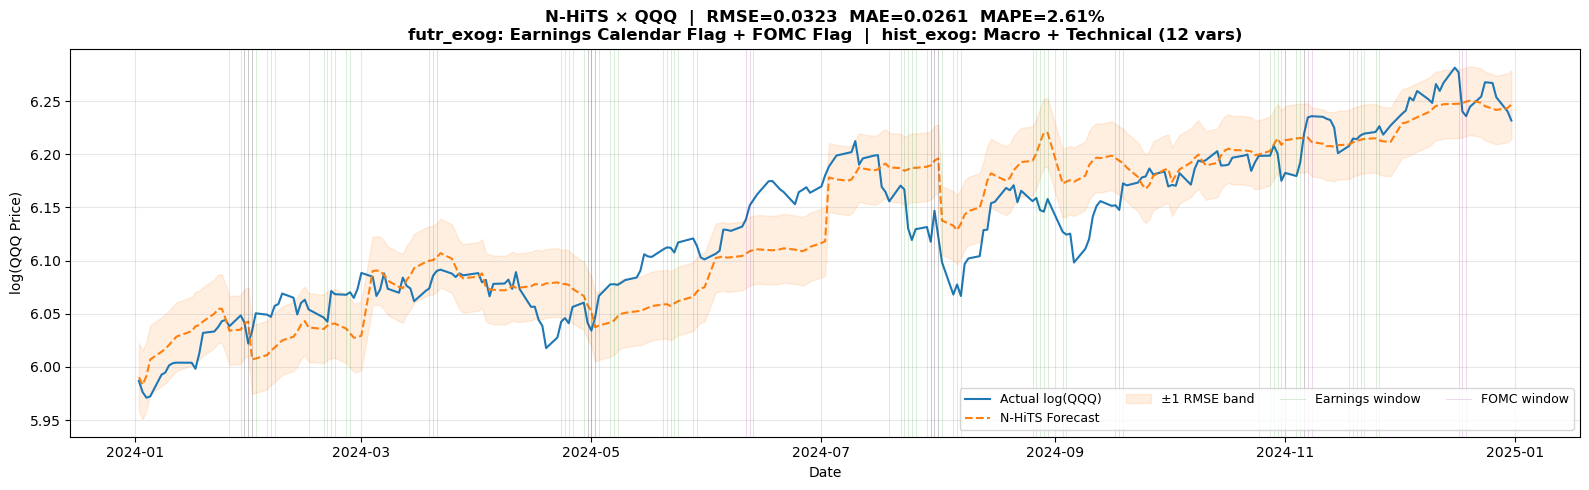

In [50]:
fig1, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(cv_clean["ds"], y_true_log, label="Actual log(QQQ)", color="#1f77b4", linewidth=1.5)
ax1.plot(cv_clean["ds"], y_pred_log, label="N-HiTS Forecast", color="#ff7f0e", linewidth=1.5, linestyle="--")
ax1.fill_between(cv_clean["ds"], y_pred_log - rmse_log, y_pred_log + rmse_log,
                 alpha=0.12, color="#ff7f0e", label="±1 RMSE band")
for i, ed in enumerate(earn_event_days):
    ax1.axvline(ed, color="green", alpha=0.15, linewidth=0.7, label="Earnings window" if i == 0 else "")
for i, fd in enumerate(fomc_event_days):
    ax1.axvline(fd, color="purple", alpha=0.15, linewidth=0.7, label="FOMC window" if i == 0 else "")
ax1.set_title(f"N-HiTS × QQQ  |  RMSE={rmse_log:.4f}  MAE={mae_log:.4f}  MAPE={mape:.2f}%\n"
              f"futr_exog: Earnings Calendar Flag + FOMC Flag  |  hist_exog: Macro + Technical (12 vars)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Date"); ax1.set_ylabel("log(QQQ Price)")
ax1.legend(fontsize=9, ncol=4); ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig1_forecast_log.png", dpi=150, bbox_inches="tight")
plt.show()

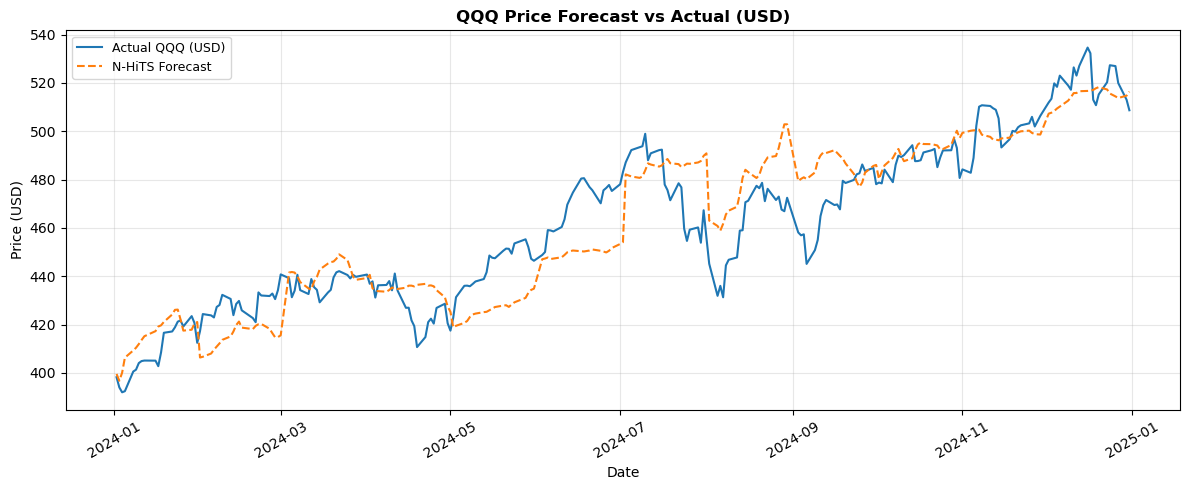

In [51]:
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(cv_clean["ds"], y_true_price, label="Actual QQQ (USD)", color="#1f77b4", linewidth=1.5)
ax2.plot(cv_clean["ds"], y_pred_price, label="N-HiTS Forecast", color="#ff7f0e", linewidth=1.5, linestyle="--")
ax2.set_title("QQQ Price Forecast vs Actual (USD)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Date"); ax2.set_ylabel("Price (USD)")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig2_forecast_price.png", dpi=150, bbox_inches="tight")
plt.show()

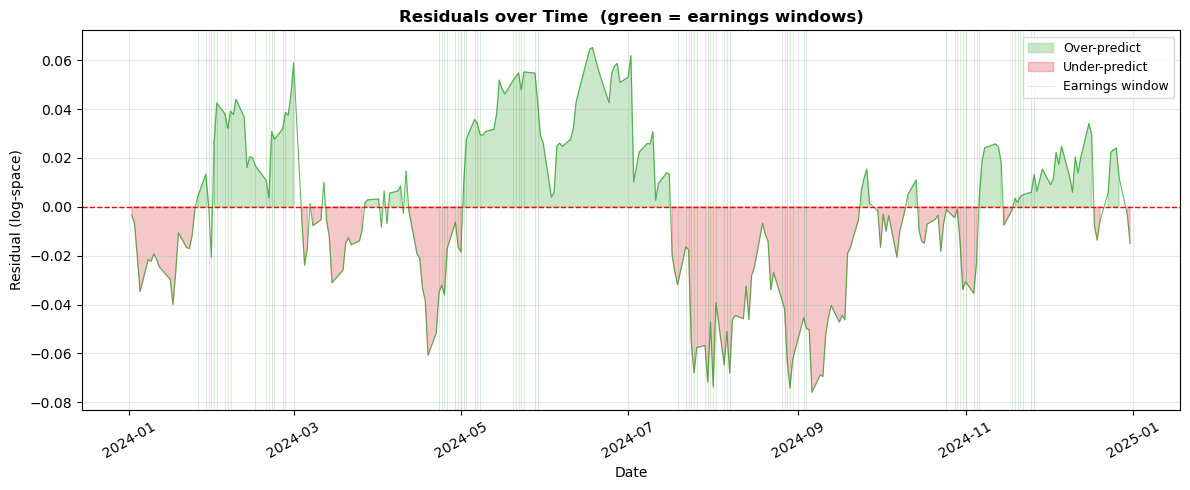

In [52]:
fig3, ax3 = plt.subplots(figsize=(12, 5))
ax3.plot(cv_clean["ds"], residuals, color="#2ca02c", linewidth=0.8, alpha=0.75)
ax3.axhline(0, color="red", linestyle="--", linewidth=1)
ax3.fill_between(cv_clean["ds"], residuals, 0, where=(residuals > 0), alpha=0.25, color="#2ca02c", label="Over-predict")
ax3.fill_between(cv_clean["ds"], residuals, 0, where=(residuals < 0), alpha=0.25, color="#d62728", label="Under-predict")
for i, ed in enumerate(earn_event_days):
    ax3.axvline(ed, color="green", alpha=0.15, linewidth=0.7, label="Earnings window" if i == 0 else "")
ax3.set_title("Residuals over Time  (green = earnings windows)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Date"); ax3.set_ylabel("Residual (log-space)")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
ax3.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig3_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

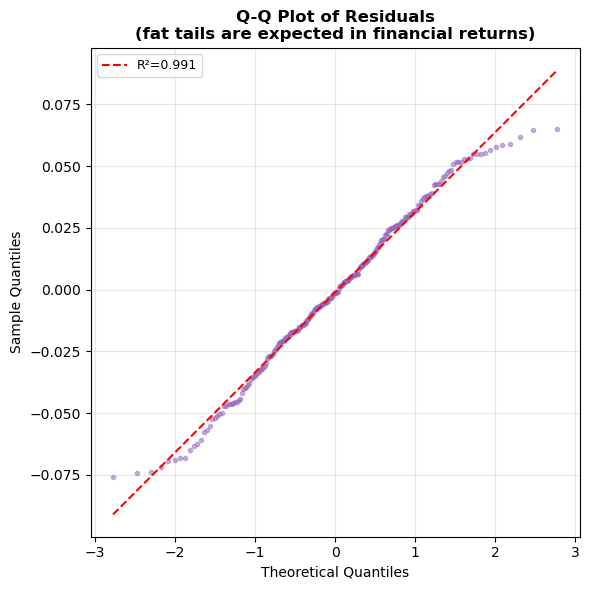

In [53]:
fig4, ax4 = plt.subplots(figsize=(6, 6))
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax4.plot(osm, osr, "o", markersize=3, color="#9467bd", alpha=0.5)
ax4.plot(osm, slope * np.array(osm) + intercept, "r--", linewidth=1.5, label=f"R²={r**2:.3f}")
ax4.set_title("Q-Q Plot of Residuals\n(fat tails are expected in financial returns)",
              fontsize=12, fontweight="bold")
ax4.set_xlabel("Theoretical Quantiles"); ax4.set_ylabel("Sample Quantiles")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig4_qqplot.png", dpi=150, bbox_inches="tight")
plt.show()

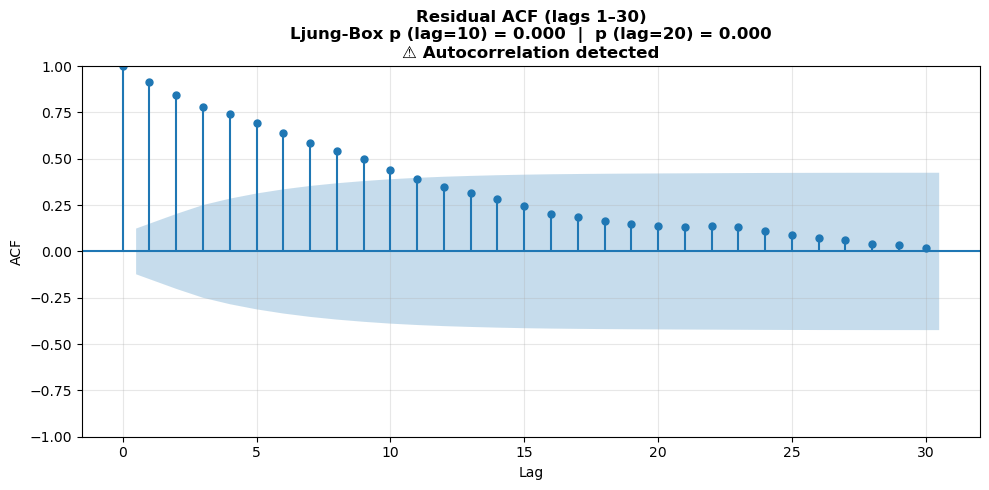

In [54]:
fig5, ax5 = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=30, ax=ax5, color="#1f77b4", alpha=0.05)
ax5.set_title(
    f"Residual ACF (lags 1–30)\n"
    f"Ljung-Box p (lag=10) = {lb_p10:.3f}  |  p (lag=20) = {lb_p20:.3f}\n"
    + ("⚠️ Autocorrelation detected" if lb_p10 < 0.05 else "✅ No significant autocorrelation"),
    fontsize=12, fontweight="bold"
)
ax5.set_xlabel("Lag"); ax5.set_ylabel("ACF")
ax5.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_acf.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
print("=" * 65)
print("FINAL SUMMARY")
print("=" * 65)

summary = {
    "Horizon (H)"               : H,
    "Input size"                : INPUT_SIZE,
    "hist_exog count"           : len(HIST_EXOG),
    "futr_exog count"           : len(FUTR_EXOG),
    "Train samples"             : len(train_df),
    "Val samples"               : len(val_df),
    "Test samples"              : len(test_df),
    "Earnings flag non-zero days": int((weighted_flag > 0).sum()),
    "FOMC flag days"            : int(fomc_flag.sum()),
    "RMSE (log)"                : round(rmse_log, 6),
    "MAE  (log)"                : round(mae_log, 6),
    "RMSE (USD)"                : round(rmse_price, 4),
    "MAE  (USD)"                : round(mae_price, 4),
    "MAPE (%)"                  : round(mape, 2),
    "Ljung-Box p (lag=10)"      : round(lb_p10, 4),
    "Ljung-Box p (lag=20)"      : round(lb_p20, 4),
    "Training time (s)"         : round(train_time, 1),
}
for k, v in summary.items():
    print(f"  {k:<32} : {v}")

FINAL SUMMARY
  Horizon (H)                      : 21
  Input size                       : 63
  hist_exog count                  : 12
  futr_exog count                  : 2
  Train samples                    : 5283
  Val samples                      : 501
  Test samples                     : 252
  Earnings flag non-zero days      : 344
  FOMC flag days                   : 123
  RMSE (log)                       : 0.032262
  MAE  (log)                       : 0.026085
  RMSE (USD)                       : 14.7864
  MAE  (USD)                       : 11.9441
  MAPE (%)                         : 2.61
  Ljung-Box p (lag=10)             : 0.0
  Ljung-Box p (lag=20)             : 0.0
  Training time (s)                : 215.0


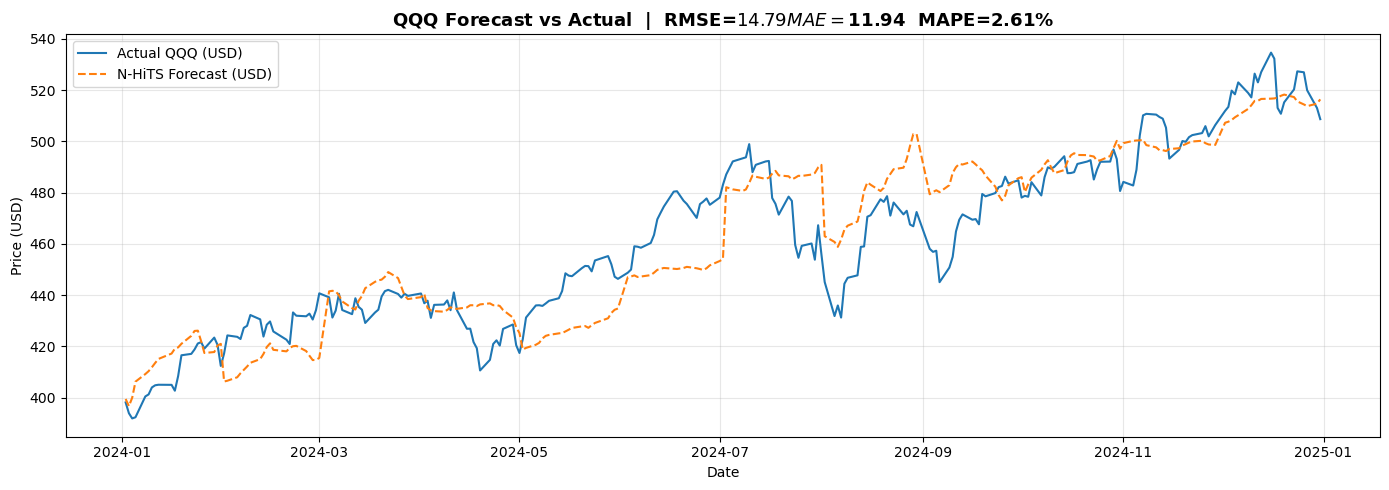

In [56]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(cv_clean["ds"], y_true_price, 
        label="Actual QQQ (USD)", color="#1f77b4", linewidth=1.5)
ax.plot(cv_clean["ds"], y_pred_price, 
        label="N-HiTS Forecast (USD)", color="#ff7f0e", linewidth=1.5, linestyle="--")

ax.set_title(f"QQQ Forecast vs Actual  |  RMSE=${rmse_price:.2f}  MAE=${mae_price:.2f}  MAPE={mape:.2f}%",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("forecast_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()